In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x0=2.8
v0=0
m=1
T=100
dx=1e-3

In [3]:
def phi(x, l1=1, l2=1/np.sqrt(8)):
    return -np.exp(-x**2/l1**2)-8*np.exp(-(x-2)**2/l2**2)

In [4]:
def acceleration(x, mass=m, deltax=dx):
    return -1/mass * (phi(x + deltax) - phi(x - deltax)) / (2*deltax)

In [5]:
def energy(x, v, mass=m):
    return 0.5*mass*v**2+phi(x)

In [6]:
def integrate(x0, v0, dt, T, method, mass=m, deltax=dx):
    N=int(np.floor(T/dt))  
    t_arr=np.zeros(N+1)
    x_arr=np.zeros(N+1)
    v_arr=np.zeros(N+1)
    E_arr=np.zeros(N+1)
    
    x_arr[0]=x0
    v_arr[0]=v0
    E_arr[0]=energy(x0, v0)
    
    for i in range(N):
        x_arr[i+1], v_arr[i+1] = method(x_arr[i], v_arr[i], dt, mass, deltax)
        t_arr[i+1] = t_arr[i] + dt
        E_arr[i+1] = energy(x_arr[i+1], v_arr[i+1])
    return t_arr, x_arr, v_arr, E_arr

In [7]:
def euler(xn, vn, dt, mass=m, deltax=dx):
    an = acceleration(xn, mass, deltax)
    return (xn+vn*dt), (vn+an*dt)

In [ ]:
t_eu, x_eu, v_eu, E_eu= integrate(x0, v0, dt = 1e-6, T = T, method = euler)

In [79]:
def verlet(xn, vn, dt, mass=m, deltax=dx):
    an=acceleration(xn, mass, deltax)
    x_new=xn+vn*dt+0.5*an*(dt**2)
    an1 = acceleration(x_new, mass, deltax)
    v_new = vn + 0.5*(an + an1)*dt
    return x_new, v_new

In [45]:
t_ver, x_ver, v_ver, E_ver = integrate(x0, v0, dt = 1e-4, T = T, method = verlet)

In [80]:
def rk4(xn, vn, dt, mass=m, deltax=dx):
    def f(x, v):
        return np.array([v, acceleration(x, mass, deltax)])
    
    k1 = f(xn, vn)
    k2 = f(xn + 0.5*dt*k1[0], vn + 0.5*dt*k1[1])
    k3 = f(xn + 0.5*dt*k2[0], vn + 0.5*dt*k2[1])
    k4 = f(xn + dt*k3[0], vn + dt*k3[1])
    
    x_new = xn + (dt/6.0)*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
    v_new = vn + (dt/6.0)*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
    return x_new, v_new


In [47]:
t_rk4, x_rk4, v_rk4, E_rk4= integrate(x0, v0, dt = 1e-3, T = T, method = rk4)

In [51]:
t_arr = [t_eu, t_ver, t_rk4]
x_arr = [x_eu, x_ver, x_rk4]
v_arr = [v_eu, v_ver, v_rk4]
E_arr = [E_eu, E_ver, E_rk4]
method_arr = ["Euler", "Verlet", "RK4"]

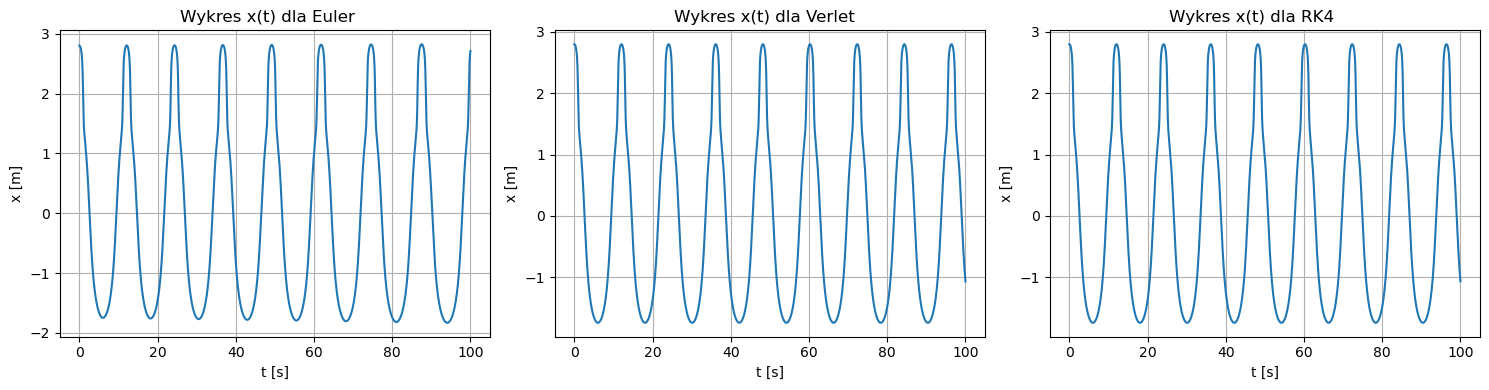

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    axes[i].plot(t_arr[i], x_arr[i])
    axes[i].set_title("Wykres x(t) dla {0:8s}".format(method_arr[i]))
    axes[i].set_xlabel("t [s]")    
    axes[i].set_ylabel("x [m]")    
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
colors = ['palevioletred', 'maroon', 'steelblue']

plt.figure(figsize=(10, 5))

for i in range(3):
    plt.plot(t_arr[i], x_arr[i], label=method_arr[i], color=colors[i])

plt.title("Wykres x(t) dla różnych metod całkowania")
plt.xlabel("t [s]")
plt.ylabel("x [m]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


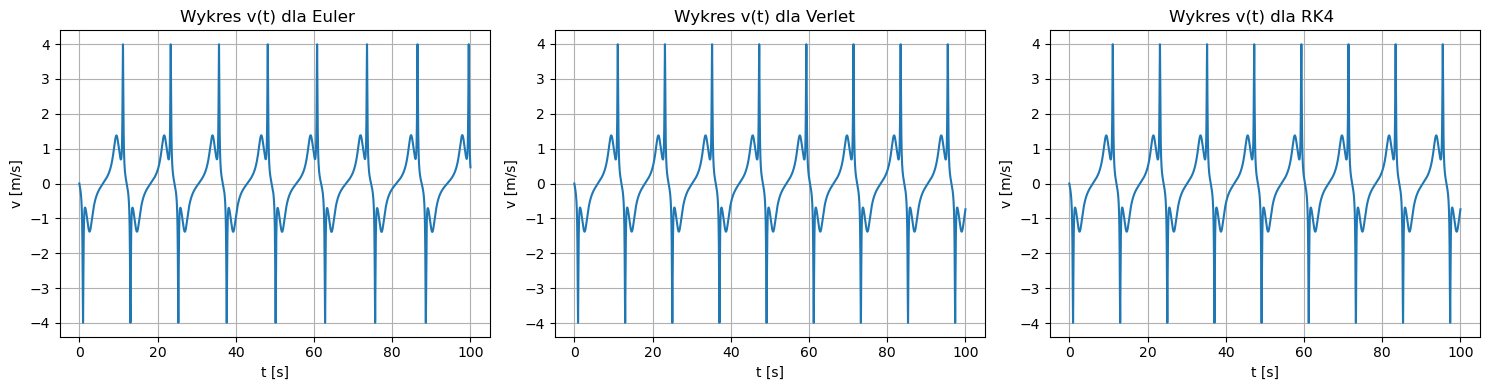

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    axes[i].plot(t_arr[i], v_arr[i])
    axes[i].set_title("Wykres v(t) dla {0:8s}".format(method_arr[i]))
    axes[i].set_xlabel("t [s]")   
    axes[i].set_ylabel("v [m/s]")    
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(3):
    plt.plot(t_arr[i], v_arr[i], label=method_arr[i], color=colors[i])

plt.title("Wykres v(t) dla różnych metod całkowania")
plt.xlabel("t [s]")
plt.ylabel("v [m/s]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

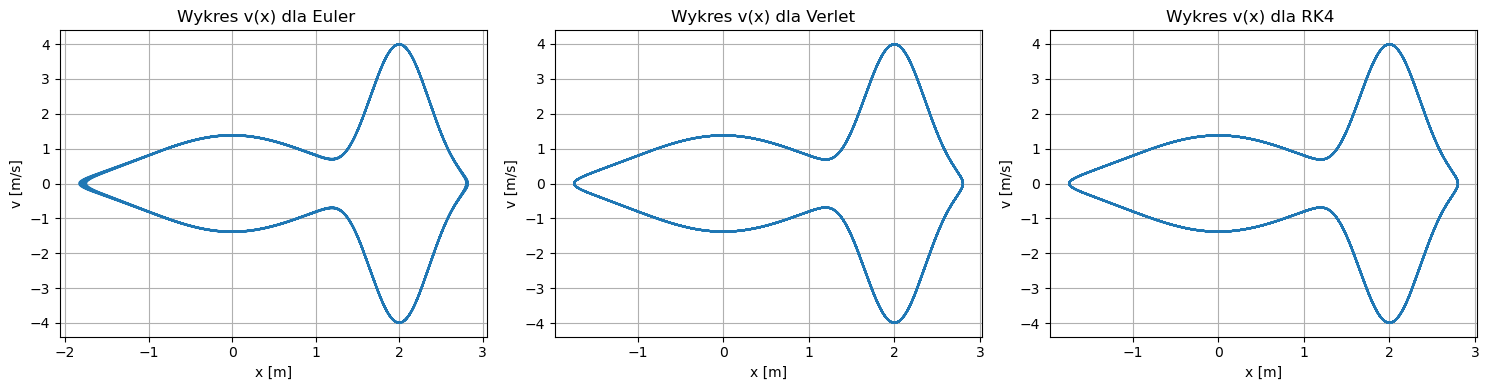

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    axes[i].plot(x_arr[i], v_arr[i])
    axes[i].set_title("Wykres v(x) dla {0:8s}".format(method_arr[i]))
    axes[i].set_xlabel("x [m]")   
    axes[i].set_ylabel("v [m/s]")    
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(3):
    plt.plot(x_arr[i], v_arr[i], label=method_arr[i], color=colors[i])

plt.title("Wykres v(x) dla różnych metod całkowania")
plt.xlabel("x [m]")
plt.ylabel("v [m/s]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

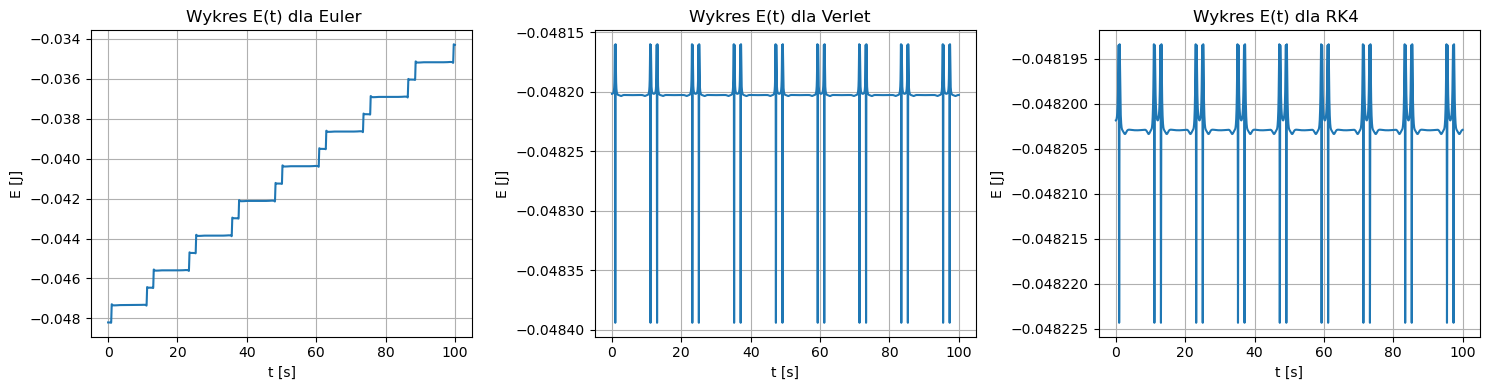

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    axes[i].plot(t_arr[i], E_arr[i])
    axes[i].set_title("Wykres E(t) dla {0:8s}".format(method_arr[i]))
    axes[i].set_xlabel("t [s]")    
    axes[i].set_ylabel("E [J]")   
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(3):
    plt.plot(t_arr[i], E_arr[i], label=method_arr[i], color=colors[i])

plt.title("Wykres E(t) dla różnych metod całkowania")
plt.xlabel("t [s]")
plt.ylabel("E [J]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Badanie zbieżności

In [81]:
def convergence(method, method_name, dts, x_ref, target_time = 1.1):
    x_errs = np.array([])
    for dt in dts:
        _, x, _, _ = integrate(x0, v0, dt = dt, T = target_time, method = method)
        x_errs = np.append(x_errs, abs(x[-1] - x_ref))
    return x_errs

In [82]:
from scipy.stats import linregress

def estimate_order(dts, errors, method_name):
    log_dt = np.log10(dts)
    log_err = np.log10(errors)

    slope, intercept, r_value, _, std_err = linregress(log_dt, log_err)
    
    print(f"Szacowany rząd zbieżności dla metody {method_name}: {slope:.2f}({abs(std_err):.2f})")
    print(f"R² dopasowania: {r_value**2:.5f}")
    

In [116]:
target_time = 1.1
dts_rk4 = [1e-1, 5e-2, 1e-2, 5e-3, 1e-3, 5e-4]
dts_verlet = dts_rk4 + [1e-4, 5e-5, 1e-5, 5e-6]
dts_euler = dts_verlet + [1e-6, 5e-7, 1e-7]

In [110]:
_, x_r, _, _ = integrate(x0, v0, dt = 1e-7, T = target_time, method = rk4)
x_ref = x_r[-1]

In [111]:
x_errs_euler = convergence(euler, "Eulera", dts_euler, x_ref)

In [117]:
x_errs_verlet = convergence(verlet, "Verleta", dts_verlet, x_ref)

In [118]:
x_errs_rk4 = convergence(rk4, "RK4", dts_rk4, x_ref)

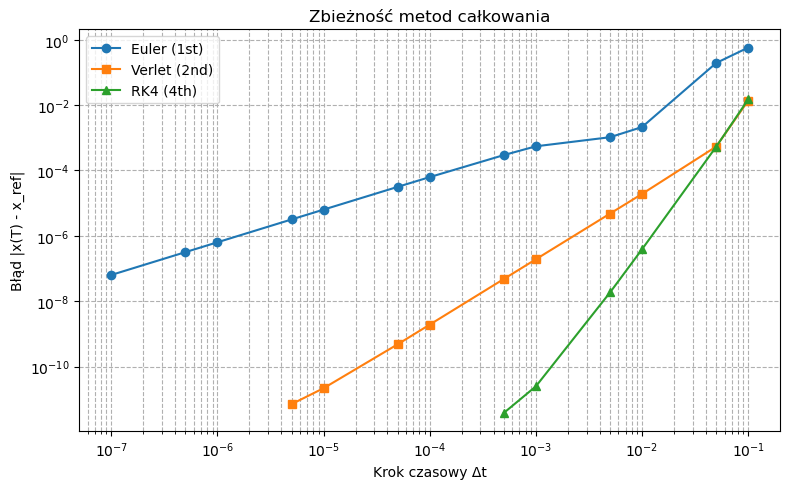

In [119]:
plt.figure(figsize=(8,5))
plt.loglog(dts_euler, x_errs_euler, 'o-', label='Euler (1st)')
plt.loglog(dts_verlet, x_errs_verlet, 's-', label='Verlet (2nd)')
plt.loglog(dts_rk4, x_errs_rk4, '^-', label='RK4 (4th)')
plt.xlabel('Krok czasowy Δt')
plt.ylabel('Błąd |x(T) - x_ref|')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.title("Zbieżność metod całkowania")
plt.tight_layout()
plt.show()

In [120]:
estimate_order(dts_euler[4:], x_errs_euler[4:], "Eulera")
estimate_order(dts_verlet, x_errs_verlet, "Verleta")
estimate_order(dts_rk4, x_errs_rk4, "RK4")

Szacowany rząd zbieżności dla metody Eulera: 0.99(0.00)
R² dopasowania: 0.99988
Szacowany rząd zbieżności dla metody Verleta: 2.07(0.06)
R² dopasowania: 0.99395
Szacowany rząd zbieżności dla metody RK4: 4.22(0.12)
R² dopasowania: 0.99682
